In [1]:
import os
import json
import pickle
import joblib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.sparse import load_npz
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device set to: {DEVICE}")

# Define Directories
ARTIFACT_DIR = '/kaggle/input/datasets/sherrytelli/bookbuddy-preprocessed/bookbuddy_artifacts'
MODEL_DIR = '/kaggle/input/models/sherrytelli/sasrec-bpr/pytorch/default/2'  # Pointing to the models saved in Phase 1
NB_DIR = '/kaggle/input/models/sherrytelli/nbc/scikitlearn/default/1'

print("📦 Loading datasets and artifacts...")

train_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'train.parquet'))
test_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'test.parquet'))

with open(os.path.join(ARTIFACT_DIR, 'artifacts.pkl'), 'rb') as f:
    artifacts = pickle.load(f)

n_users = len(artifacts['user_map'])
n_books = len(artifacts['book_map'])
reverse_book_map = {v: k for k, v in artifacts['book_map'].items()}

THRESHOLD = 4
def to_implicit(df):
    df = df.copy()
    df['label'] = (df['rating'] >= THRESHOLD).astype(int)
    return df[['user_idx', 'book_idx', 'label']]

train_imp = to_implicit(train_df)
test_imp = to_implicit(test_df)

# Fast-lookup dictionary for chronological sequences
train_seqs = train_imp.sort_values('user_idx').groupby('user_idx')['book_idx'].apply(list).to_dict()

print(f"✅ Data loaded! Matrix dims: {n_users:,} users × {n_books:,} books")

✅ Device set to: cuda
📦 Loading datasets and artifacts...
✅ Data loaded! Matrix dims: 53,424 users × 8,726 books


In [2]:
# 1. Re-define the Hybrid SASRec Architecture
class HybridSASRec(nn.Module):
    def __init__(self, num_users, num_items, max_seq_len=20, embed_dim=64, num_heads=2, num_layers=2, dropout=0.3):
        super(HybridSASRec, self).__init__()
        
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items + 1, embed_dim, padding_idx=0) 
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, users, seqs, target_item_idx):
        # 1. Embed the input sequence and add positional encodings
        seq_embeds = self.item_embed(seqs)
        positions = torch.arange(seqs.size(1), device=seqs.device).unsqueeze(0).expand_as(seqs)
        pos_embeds = self.pos_embed(positions)
        
        x = seq_embeds + pos_embeds
        padding_mask = (seqs == 0)
        
        # 2. Pass through Transformer & get final sequence state
        out = self.transformer(x, src_key_padding_mask=padding_mask)
        seq_reps = out[:, -1, :] 
        
        # 3. Get inherent User Embedding (acts like the MLP user state)
        u_reps = self.user_embed(users)
        
        # 4. Combine Collaborative User Rep + Sequential Rep
        combined_reps = seq_reps + u_reps
        
        # 5. Get embedding for the target item (positive or negative)
        item_reps = self.item_embed(target_item_idx)
        
        # 6. Dot product for final affinity score
        scores = (combined_reps * item_reps).sum(dim=1)
        return scores

# 2. Load the Optimized SASRec Weights
model_config = torch.load(os.path.join(MODEL_DIR, 'sasrec_config_1.pt'), map_location=DEVICE)
sasrec_model = HybridSASRec(
    num_users=model_config['n_users'], 
    num_items=model_config['n_books'], 
    embed_dim=model_config['embed_dim'], 
    dropout=model_config['dropout']
).to(DEVICE)

sasrec_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'sasrec_bpr_weights_1.pt'), map_location=DEVICE))
sasrec_model.eval() 
print("✅ SASRec Collaborative Model Loaded!")

# 3. Load the Naïve Bayes Model
NB_MODEL_PATH = os.path.join(NB_DIR, 'nb_proficiency_model.pkl')
try:
    nb_model = joblib.load(NB_MODEL_PATH)
    print("✅ Naïve Bayes Content Model Loaded!")
except Exception as e:
    print(f"❌ Error loading model: {e}")

✅ SASRec Collaborative Model Loaded!
✅ Naïve Bayes Content Model Loaded!


In [3]:
class HybridRecommender:
    def __init__(self, sasrec_model, nb_model, artifacts, books_df, tfidf_matrix, valid_nb_indices, device):
        self.sasrec_model = sasrec_model
        self.nb_model = nb_model 
        self.artifacts = artifacts
        self.books_df = books_df
        self.tfidf_matrix = tfidf_matrix
        self.device = device
        
        self.n_books = len(artifacts['book_map'])
        self.book_indices = torch.arange(self.n_books, device=self.device)
        self.scaler = MinMaxScaler()
        self.valid_nb_indices = set(valid_nb_indices)
        
        # Pre-compute the NBC probabilities for ALL books
        self.nb_probs = self.nb_model.predict_proba(self.tfidf_matrix)

    @torch.no_grad()
    def get_sasrec_scores(self, user_idx, seq):
        """Gets Sequential scores from SASRec & scales them to [0, 1]"""
        self.sasrec_model.eval()
        
        # Pad sequence for inference
        input_seq = seq[-20:]
        padded_seq = [0] * (20 - len(input_seq)) + input_seq
        
        users_tensor = torch.tensor([user_idx], dtype=torch.long, device=self.device)
        seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=self.device)
        
        logits = self.sasrec_model(users_tensor, seq_tensor, self.book_indices).cpu().numpy().flatten()
        scaled_scores = self.scaler.fit_transform(logits.reshape(-1, 1)).flatten()
        return scaled_scores

    def get_user_preferred_level(self, seq):
        """Determines the user's dominant reading level from their history"""
        if not seq: 
            return 1 ## Default to Intermediate (B1) if brand new user
            
        # Look up the proficiency labels of the books they've read
        read_levels = self.books_df.loc[seq, 'proficiency_label'].dropna()
        
        if len(read_levels) == 0:
            return 1

        # Return their most frequent reading level (0, 1, 2, or 3)
        return int(read_levels.mode()[0])

    def get_nb_scores(self, seq):
        """Content Score = Probability that the book matches the user's reading level"""
        preferred_level = self.get_user_preferred_level(seq)
        
         # Slice the probability matrix to get the scores for their specific level
        return self.nb_probs[:, preferred_level]

    def recommend(self, user_idx, alpha=0.7, top_k=10, seq=[]):
        """Fuses scores using alpha (SASRec weight) and 1-alpha (NB weight)"""
        sasrec_scores = self.get_sasrec_scores(user_idx, seq)
        nb_scores = self.get_nb_scores(seq)
        
        final_scores = np.zeros(self.n_books)
        
        for i in range(self.n_books):
            if i not in self.valid_nb_indices:
                final_scores[i] = sasrec_scores[i]
            else:
                nb_penalty = (alpha) + ((1 - alpha) * nb_scores[i])
                final_scores[i] = sasrec_scores[i] * nb_penalty
            
        if seq:
            final_scores[seq] = -float('inf')
            
        top_k_indices = np.argsort(final_scores)[::-1][:top_k]
        recommendations = [reverse_book_map[idx] for idx in top_k_indices]
        
        return recommendations, final_scores[top_k_indices]

print("✅ Smart HybridRecommender Class compiled successfully!")

✅ Smart HybridRecommender Class compiled successfully!


In [4]:
# 1. Load the Book Metadata & TF-IDF Matrix
books_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'books_clean.parquet'))
tfidf_matrix = load_npz(os.path.join(ARTIFACT_DIR, 'tfidf_matrix.npz'))

# 2. Map the text labels to match NBC training
level_map = {'Beginner (A2)': 0, 'Intermediate (B1)': 1, 'Advanced (B2)': 2, 'Expert (C1)': 3}
books_df['proficiency_label'] = books_df['proficiency_level'].map(level_map)

# 3. Identify valid books
valid_nb_indices = books_df[books_df['proficiency_level'] != 'Unknown'].index.values

# 4. Initialize the Hybrid Engine
hybrid_engine = HybridRecommender(
    sasrec_model=sasrec_model, 
    nb_model=nb_model, 
    artifacts=artifacts, 
    books_df=books_df, 
    tfidf_matrix=tfidf_matrix, 
    valid_nb_indices=valid_nb_indices, 
    device=DEVICE
)
print("✅ Hybrid Engine Initialized!")

# 5. Test Inference
SAMPLE_USER_IDX = 42 
user_seq = train_seqs.get(SAMPLE_USER_IDX, [])

recs, scores = hybrid_engine.recommend(user_idx=SAMPLE_USER_IDX, alpha=0.9, top_k=5, seq=user_seq)

print(f"\n📚 Top 5 Hybrid Recommendations for User {SAMPLE_USER_IDX}:")
for rank, (book_id, score) in enumerate(zip(recs, scores), 1):
    print(f"{rank}. Goodreads Book ID: {book_id} | Hybrid Score: {score:.4f}")

✅ Hybrid Engine Initialized!

📚 Top 5 Hybrid Recommendations for User 42:
1. Goodreads Book ID: 5 | Hybrid Score: 0.9498
2. Goodreads Book ID: 11 | Hybrid Score: 0.9202
3. Goodreads Book ID: 28 | Hybrid Score: 0.9127
4. Goodreads Book ID: 32 | Hybrid Score: 0.9094
5. Goodreads Book ID: 30 | Hybrid Score: 0.9051


🎯 PHASE 5: ALPHA PARAMETER TUNING
🔍 Searching for the optimal Alpha (Collaborative Weight)...
   Alpha: 0.0 | NDCG@10: 0.0483
   Alpha: 0.1 | NDCG@10: 0.0564
   Alpha: 0.2 | NDCG@10: 0.0552
   Alpha: 0.3 | NDCG@10: 0.0579
   Alpha: 0.4 | NDCG@10: 0.0552
   Alpha: 0.5 | NDCG@10: 0.0591
   Alpha: 0.6 | NDCG@10: 0.0571
   Alpha: 0.7 | NDCG@10: 0.0686
   Alpha: 0.8 | NDCG@10: 0.0724
   Alpha: 0.9 | NDCG@10: 0.0964
   Alpha: 1.0 | NDCG@10: 0.0872

🏆 Optimal Alpha Found: 0.9 (NDCG@10 = 0.0964)


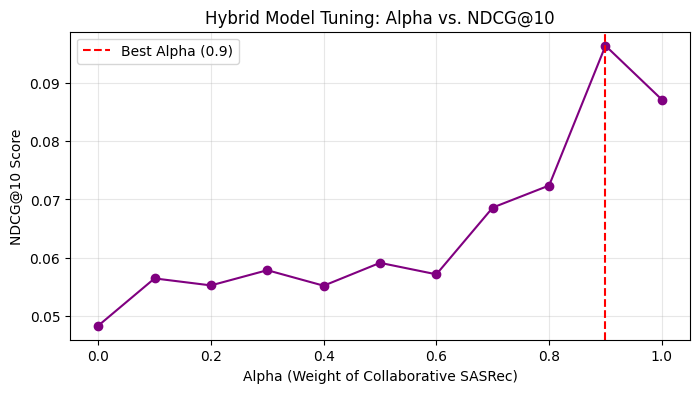

In [6]:
print("="*70)
print("🎯 PHASE 5: ALPHA PARAMETER TUNING")
print("="*70)

def evaluate_hybrid_fast(hybrid_engine, train_df, test_df, reverse_book_map, alpha, k=10, n_eval_users=300):
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    valid_users = list(test_by_user.keys())
    sampled_users = np.random.choice(valid_users, size=min(n_eval_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    
    for u_idx in sampled_users:
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal}
        seq = train_seqs.get(u_idx, [])
        
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=k, seq=seq)
        
        n_rel = len(gt_items)
        if n_rel == 0: continue
            
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recs) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            
    return np.mean(ndcg_scores)

alphas_to_test = np.arange(0.0, 1.1, 0.1)
tuning_results = []

print("🔍 Searching for the optimal Alpha (Collaborative Weight)...")
for a in alphas_to_test:
    score = evaluate_hybrid_fast(hybrid_engine, train_imp, test_imp, reverse_book_map, alpha=a)
    tuning_results.append(score)
    print(f"   Alpha: {a:.1f} | NDCG@10: {score:.4f}")

best_alpha_idx = np.argmax(tuning_results)
best_alpha = alphas_to_test[best_alpha_idx]
peak_ndcg = tuning_results[best_alpha_idx]

print(f"\n🏆 Optimal Alpha Found: {best_alpha:.1f} (NDCG@10 = {peak_ndcg:.4f})")

plt.figure(figsize=(8, 4))
plt.plot(alphas_to_test, tuning_results, marker='o', linestyle='-', color='purple')
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best Alpha ({best_alpha:.1f})')
plt.title('Hybrid Model Tuning: Alpha vs. NDCG@10')
plt.xlabel('Alpha (Weight of Collaborative SASRec)')
plt.ylabel('NDCG@10 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🎯 PHASE 6: COMPREHENSIVE HYBRID EVALUATION (Alpha = 0.9)
📈 TEST SET EVALUATION (Full Population)
----------------------------------------------------------------------


Evaluating users:   0%|          | 0/53172 [00:00<?, ?it/s]

Evaluated 53,172 users with test interactions

Precision@5:  0.0798
Recall@5:     0.0375
NDCG@5:       0.0860

Precision@10:  0.0666
Recall@10:     0.0625
NDCG@10:       0.0799

Precision@20:  0.0545
Recall@20:     0.1016
NDCG@20:       0.0916

🧊 COLD-START ROBUSTNESS ANALYSIS
----------------------------------------------------------------------
Simulating cold-start scenarios (NDCG@10):
History kept: 100%   | NDCG@10: 0.0793 ± 0.1170
History kept: 50%    | NDCG@10: 0.0614 ± 0.1057
History kept: 25%    | NDCG@10: 0.0550 ± 0.0902
History kept: 9%     | NDCG@10: 0.0579 ± 0.0923


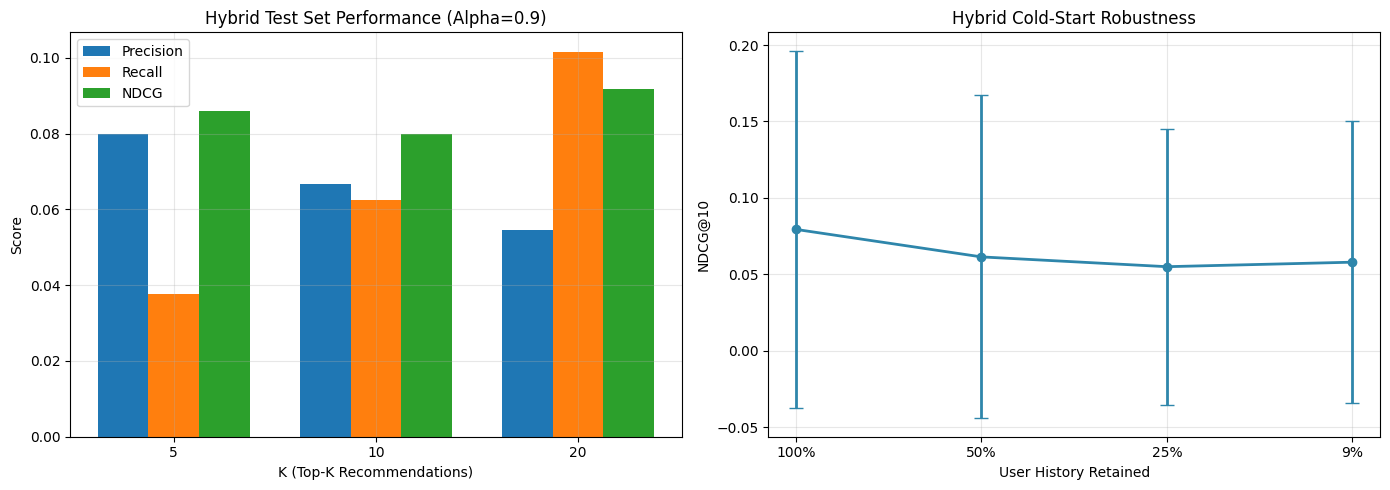

In [7]:
print("="*70)
print(f"🎯 PHASE 6: COMPREHENSIVE HYBRID EVALUATION (Alpha = {best_alpha:.1f})")
print("="*70)

# --- A. Full Test Set Evaluation ---
print("📈 TEST SET EVALUATION (Full Population)")
print("-" * 70)

def evaluate_hybrid_full(hybrid_engine, test_df, reverse_book_map, alpha, k_values=[5, 10, 20]):
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    metrics = {f'Precision@{k}': [] for k in k_values}
    metrics.update({f'Recall@{k}': [] for k in k_values})
    metrics.update({f'NDCG@{k}': [] for k in k_values})
    
    evaluated_users = 0
    for u_idx in tqdm(test_by_user.keys(), desc="Evaluating users"):
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal} 
        seq = train_seqs.get(u_idx, [])
        if len(gt_items) == 0: continue
        
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=max(k_values), seq=seq)
        n_rel = len(gt_items)
        
        for k in k_values:
            top_k_recs = recs[:k]
            hits = len(set(top_k_recs).intersection(gt_items))
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_recs) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            metrics[f'Precision@{k}'].append(prec)
            metrics[f'Recall@{k}'].append(rec)
            metrics[f'NDCG@{k}'].append(ndcg)
            
        evaluated_users += 1
    
    return {k: np.mean(v) for k, v in metrics.items()}, evaluated_users

hybrid_metrics, n_test_users = evaluate_hybrid_full(hybrid_engine, test_imp, reverse_book_map, alpha=best_alpha, k_values=[5, 10, 20])

print(f"Evaluated {n_test_users:,} users with test interactions\n")
for k in [5, 10, 20]:
    print(f"Precision@{k}:  {hybrid_metrics[f'Precision@{k}']:.4f}")
    print(f"Recall@{k}:     {hybrid_metrics[f'Recall@{k}']:.4f}")
    print(f"NDCG@{k}:       {hybrid_metrics[f'NDCG@{k}']:.4f}\n")

# --- B. Sequential Cold-Start Simulation ---
print("="*70)
print("🧊 COLD-START ROBUSTNESS ANALYSIS")
print("-" * 70)

def simulate_hybrid_cold_start(hybrid_engine, test_df, reverse_book_map, alpha, mask_ratio=0.75, k=10, n_users=500):
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    valid_users = [u for u in train_seqs if len(train_seqs[u]) > 10 and u in test_by_user]
    sampled_users = np.random.choice(valid_users, size=min(n_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    for u_idx in sampled_users:
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal}
        seq = train_seqs.get(u_idx, [])
        if len(gt_items) == 0 or len(seq) == 0: continue
        
        # Chronological Truncation
        n_keep = max(1, int(len(seq) * (1 - mask_ratio)))
        kept_seq = seq[:n_keep]
        
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=k, seq=kept_seq)
        
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recs) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(gt_items), k)))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores), np.std(ndcg_scores)

hybrid_cold_start_results = {}
print("Simulating cold-start scenarios (NDCG@10):")
for mask_ratio in [0.0, 0.5, 0.75, 0.9]:
    mean_ndcg, std_ndcg = simulate_hybrid_cold_start(hybrid_engine, test_imp, reverse_book_map, best_alpha, mask_ratio=mask_ratio, k=10, n_users=500)
    hybrid_cold_start_results[mask_ratio] = {'mean': mean_ndcg, 'std': std_ndcg}
    history_kept = f"{int((1-mask_ratio)*100)}%"
    print(f"History kept: {history_kept:6} | NDCG@10: {mean_ndcg:.4f} ± {std_ndcg:.4f}")

# --- C. Save & Visualize ---
final_artifacts = {
    'hybrid_test_metrics': hybrid_metrics,
    'hybrid_cold_start_results': hybrid_cold_start_results,
    'hybrid_config': {'optimal_alpha': float(best_alpha), 'fusion_type': 'Multiplicative Penalty'}
}
EVAL_DIR = 'evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)
with open(os.path.join(EVAL_DIR, 'hybrid_evaluation_results.json'), 'w') as f:
    json.dump(final_artifacts, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_values = [5, 10, 20]
x = np.arange(len(k_values))
width = 0.25
for i, metric in enumerate(['Precision', 'Recall', 'NDCG']):
    values = [hybrid_metrics[f'{metric}@{k}'] for k in k_values]
    axes[0].bar(x + i*width, values, width, label=f'{metric}')

axes[0].set_xlabel('K (Top-K Recommendations)')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Hybrid Test Set Performance (Alpha={best_alpha:.1f})')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

mask_ratios = list(hybrid_cold_start_results.keys())
ndcg_means = [hybrid_cold_start_results[r]['mean'] for r in mask_ratios]
ndcg_stds = [hybrid_cold_start_results[r]['std'] for r in mask_ratios]
history_pct = [f"{int((1-r)*100)}%" for r in mask_ratios]

axes[1].errorbar(history_pct, ndcg_means, yerr=ndcg_stds, marker='o', capsize=5, linewidth=2, color='#2E86AB')
axes[1].set_xlabel('User History Retained')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('Hybrid Cold-Start Robustness')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 🎓 Cell 7: Generalized LLM Re-Ranking & Explanations (Qwen2.5-7B)
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Clear residual VRAM from the training loops
print("🧹 Clearing residual VRAM...")
torch.cuda.empty_cache()
gc.collect()

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct" 

print(f"⏳ Downloading and Loading {MODEL_ID} (This takes ~2 mins)...")

# 2. Configure 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 3. Load Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto" 
)
print("✅ Generative Recommendation Agent Loaded!")

def generate_personalized_recommendation(user_idx, hybrid_engine, books_df, train_seqs, artifacts):
    # 1. Get User's Actual Reading History for Context
    seq = train_seqs.get(user_idx, [])
    history_titles = []
    
    for idx in seq[-5:]:
        real_id = reverse_book_map[idx]
        title_matches = books_df.loc[books_df[artifacts['id_col']] == real_id, 'title'].values
        if len(title_matches) > 0:
            history_titles.append(title_matches[0])
            
    history_text = "\n".join([f"- {t}" for t in history_titles]) if history_titles else "No reading history available."
    
    # 2. RUN STAGE 1 & 2 (SASRec + NBC Fusion) -> Get Top 10
    top_10_ids, _ = hybrid_engine.recommend(user_idx, alpha=best_alpha, top_k=10, seq=seq)
    
    # 3. Dynamically get the user's actual proficiency level
    level_map_reverse = {0: 'Beginner (A2)', 1: 'Intermediate (B1)', 2: 'Advanced (B2)', 3: 'Expert (C1)'}
    user_level_idx = hybrid_engine.get_user_preferred_level(seq)
    user_level_name = level_map_reverse.get(user_level_idx, "Unknown")
    
    # 4. Build Candidates Context
    candidates_text = ""
    for i, book_id in enumerate(top_10_ids, 1):
        book_info = books_df[books_df[artifacts['id_col']] == book_id].iloc[0]
        candidates_text += f"{i}. Title: {book_info['title']} | Author: {book_info['authors']} | Genre: {book_info['genres_str']} | Level: {book_info['proficiency_level']}\n"
    
    # 5. Construct Generalized Reasoning Prompt using Chat Templates
    messages = [
        {
            "role": "system", 
            "content": "You are 'BookBuddy', an expert and friendly book recommendation assistant. You analyze a reader's history and select the perfect books for them, ensuring the language complexity matches their comfort level."
        },
        {
            "role": "user", 
            "content": f"""I am looking for my next great book! My current reading proficiency is at the {user_level_name} level.

Here are the last few books I have read and enjoyed:
{history_text}

Here are 10 book candidates that match my reading level:
{candidates_text}

Task:
1. Select the BEST 3 books from the candidate list for my specific taste and reading level.
2. Output your response as a numbered list.
3. For each book, write a 1-to-2 sentence personalized justification. Reference the books I have already read to explain why this new book is a great fit for my interests and language proficiency.

Format exactly like this:
1. **[Book Title]** - [Your justification]"""
        }
    ]
    
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    
    # 6. RUN STAGE 3 (LLM Re-ranking & Generation)
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs, 
            max_new_tokens=300, 
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Extract only the newly generated text
    input_length = inputs['input_ids'].shape[1]
    response = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    
    return response.strip()

# ==========================================
# 🚀 TEST THE FULL 3-STAGE PIPELINE
# ==========================================
active_users = train_imp.groupby('user_idx').size().nlargest(5).index.tolist()
SAMPLE_USER = active_users[0]

print("\n" + "="*80)
print(f"📚 BOOKBUDDY PIPELINE FOR USER {SAMPLE_USER}")
print("="*80)
print("⏳ Stage 1 & 2: SASRec + NBC Fusion retrieving Top 10 candidates...")
print("⏳ Stage 3: Qwen2.5-7B analyzing history and generating personalized recommendations...\n")

final_recs = generate_personalized_recommendation(SAMPLE_USER, hybrid_engine, books_df, train_seqs, artifacts)
print(final_recs)
print("="*80)

🧹 Clearing residual VRAM...
⏳ Downloading and Loading Qwen/Qwen2.5-7B-Instruct (This takes ~2 mins)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Generative Recommendation Agent Loaded!

📚 BOOKBUDDY PIPELINE FOR USER 53344
⏳ Stage 1 & 2: SASRec + NBC Fusion retrieving Top 10 candidates...
⏳ Stage 3: Qwen2.5-7B analyzing history and generating personalized recommendations...

1. **The Fellowship of the Ring (The Lord of the Rings, #1)** - This book introduces you to the epic world of Middle-earth, similar to the style found in "The Throne of Fire" from the Kane Chronicles series. It will help you build your vocabulary and understanding of fantasy narratives while keeping the language at a beginner-friendly level.

2. **Lord of the Flies** - Written by William Golding, this novel explores themes of human nature and survival, which can be quite relatable after reading the adventures in "The Wee Free Men." The story is engaging and the writing style is simple enough for a beginner level, making it a perfect match for your taste.

3. **To Kill a Mockingbird** - By Harper Lee, this classic novel deals with important social issues an